### TrojanSAINT-style Sampled Inductive GNN

TrojanSAINT is a hardware-security-oriented GNN framework originally designed for gate-level hardware Trojan detection and localization. Instead of training on entire large flattened gate-level netlists at once, TrojanSAINT follows the GraphSAINT idea of sampling smaller subgraphs from a larger disconnected graph containing multiple netlists. A complete GNN is then trained on each sampled subgraph, which improves scalability and makes the model suitable for inductive evaluation on unseen circuits.

In this experiment, we adapt the TrojanSAINT principle to the four-class circuit-fault setting. Each ISCAS85/EPFL netlist is represented as a gate-level graph using the already generated `nodes_enhanced.csv` and `edges_enhanced.csv`. The model uses a GraphSAGE-style mean aggregation encoder trained with GraphSAINT-style subgraph sampling. Following the original TrojanSAINT design choice, the graph is made undirected for message passing, while the directed circuit information is still preserved in the engineered node features such as fan-in/fan-out, SCOAP controllability/observability, path depth, distance to primary outputs, and k-hop relational statistics. The task remains node-level multi-class classification over `clean`, `stuck_at`, `bridging`, and `glitch`.

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
PyG GraphSAINT available: True
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train and Test overlap: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 18

Test graph netlists and node counts:
------------------------------------
01. sqrt.v | nodes=37

/tmp/ipykernel_1253555/4287833096.py:1051: UserWarning: PyG GraphSAINTNodeSampler failed at runtime. Switching to fallback induced-subgraph sampler. Error: ImportError("'SparseTensor' requires 'torch-sparse'")
  warnings.warn(


[Epoch 001] train_loss_sampled=0.6087 train_acc_sampled=0.4183 | test_loss=1.1921 test_acc=0.4318 test_macroF1=0.3315 | best_loss=1.1921 best_epoch=1
[Epoch 005] train_loss_sampled=0.1064 train_acc_sampled=0.8709 | test_loss=0.1585 test_acc=0.9980 test_macroF1=0.8910 | best_loss=0.1585 best_epoch=5
[Epoch 010] train_loss_sampled=0.0837 train_acc_sampled=0.9504 | test_loss=0.0848 test_acc=0.9997 test_macroF1=0.9857 | best_loss=0.0848 best_epoch=10
[Epoch 015] train_loss_sampled=0.0724 train_acc_sampled=0.9659 | test_loss=0.0777 test_acc=0.9998 test_macroF1=0.9861 | best_loss=0.0672 best_epoch=12
[Epoch 020] train_loss_sampled=0.0698 train_acc_sampled=0.9730 | test_loss=0.0813 test_acc=0.9998 test_macroF1=0.9861 | best_loss=0.0672 best_epoch=12
[Epoch 025] train_loss_sampled=0.0676 train_acc_sampled=0.9757 | test_loss=0.0781 test_acc=0.9998 test_macroF1=0.9861 | best_loss=0.0672 best_epoch=12
[Epoch 030] train_loss_sampled=0.0663 train_acc_sampled=0.9776 | test_loss=0.0780 test_acc=0.999

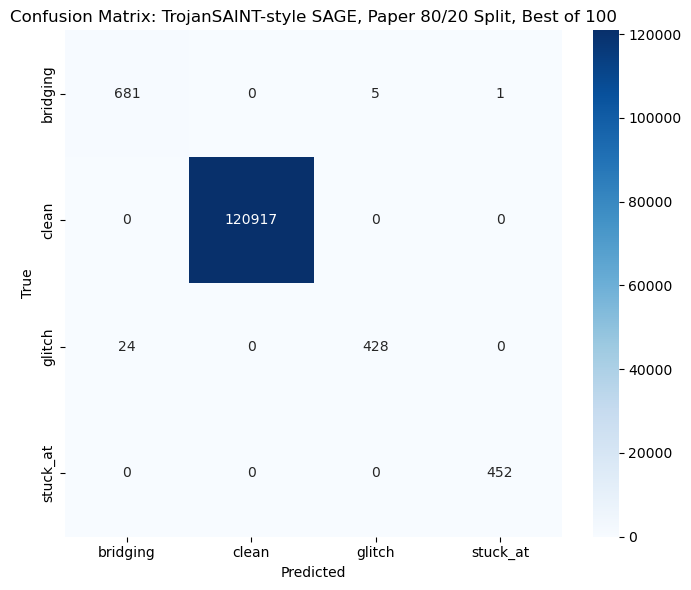


Saved checkpoint to: trojansaint_style_sage_paper_protocol_80_20_100epochs.pt


In [1]:
# ============================================================
# Paper-protocol TrojanSAINT-style Sampled Inductive GNN
# for Circuit Fault Detection from Enhanced CSVs
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# Task:
#   Node-level 4-class classification:
#   clean, bridging, glitch, stuck_at
#
# Paper-protocol refinement:
#   - 80/20 train/test split by netlist_file
#   - no separate validation split
#   - train for 100 epochs
#   - learning rate = 7e-4
#   - dropout = 0.4
#   - hidden dimension = 64
#   - train-only normalization
#   - paper-style inverse-frequency class weights
#   - best model selected by lowest monitored test loss,
#     matching the original paper-code style
#   - test netlist names are printed explicitly
#
# Architecture:
#   TrojanSAINT-style training:
#       - build one large disconnected training graph
#       - train on sampled subgraphs using GraphSAINT-style sampling
#       - GraphSAGE-style mean aggregation encoder
#       - full test evaluation on unseen held-out netlists
#
# This cell defines:
#   nodes_df, edges_df, train_nets, test_nets
# and creates empty val_nets/val_graphs placeholders for compatibility.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv
    from torch_geometric.utils import coalesce, subgraph
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required for this notebook. "
        "Install a PyG version compatible with your PyTorch/CUDA setup."
    ) from e

try:
    from torch_geometric.loader import GraphSAINTNodeSampler
    HAS_PYG_GRAPHSAINT = True
    GRAPHSAINT_IMPORT_ERROR = None
except Exception as e:
    HAS_PYG_GRAPHSAINT = False
    GRAPHSAINT_IMPORT_ERROR = e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# File paths
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# Paper-code behavior:
# prefer clean topology if available; otherwise fall back to union.
EDGE_MODE = "clean"       # choices: "clean", "union"

# TrojanSAINT used undirected gate-level graphs for representation learning.
# Directed circuit information remains present in node features.
MAKE_UNDIRECTED_FOR_MESSAGE_PASSING = True


# -------------------------
# Paper-style training hyperparameters
# -------------------------
EPOCHS = 100
LR = 7e-4
WEIGHT_DECAY = 5e-4
DROPOUT = 0.4

HID = 64
NUM_SAGE_LAYERS = 3


# -------------------------
# GraphSAINT subgraph sampling settings
# -------------------------
SAINT_BATCH_SIZE = 4096
SAINT_NUM_STEPS_PER_EPOCH = 30
SAINT_SAMPLE_COVERAGE = 0

# Used only by the fallback sampler when PyG GraphSAINT is unavailable.
FALLBACK_CLEAN_TO_FAULT_RATIO = 1.0


# -------------------------
# Printing and device
# -------------------------
PRINT_EVERY = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyG GraphSAINT available:", HAS_PYG_GRAPHSAINT)
if not HAS_PYG_GRAPHSAINT:
    print("GraphSAINT import error:", repr(GRAPHSAINT_IMPORT_ERROR))


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "in_degree", "out_degree", "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact", "dist_to_PO",
    "fanout", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node",
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


# -------------------------
# String cleanup
# -------------------------
for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


# -------------------------
# Numeric cleanup
# -------------------------
base_num_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Class labels and gate-type encoding
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError("Expected a 'clean' class in fault_type.")

clean_idx = class_to_idx["clean"]

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)


def canonical_gate_type(gate_type: str) -> str:
    """
    Paper-compatible compact gate vocabulary.

    Pseudo-fault gate names are mapped to 'other' to reduce direct leakage
    from names such as sa0, sa1, bridge, and glitch.
    """
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    # Hide explicit pseudo-fault names.
    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    # Common logic gates.
    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 netlist-level train/test split
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test split."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)

train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train and Test overlap:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# Compatibility placeholders in case another helper cell expects val_nets/val_graphs.
# This notebook intentionally follows the paper's train/test-only protocol.
val_nets = np.array([], dtype=object)
val_graphs = []


# ============================================================
# 5. Build one joint graph per netlist
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    """
    Return edges for a single netlist.

    EDGE_MODE='clean':
        Use clean topology if available. This mirrors the original
        paper-code style. Fall back to union if clean topology is unavailable.

    EDGE_MODE='union':
        Use clean + faulted topology and deduplicate src/dst.
    """
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    use_e = (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )

    return use_e


def build_joint_graphs(nets: np.ndarray) -> List[Data]:
    """
    Build one node-classification graph per netlist.

    Node set:
        Union of clean and faulted nodes.

    Labels:
        Start every node as clean.
        Any non-clean row with label==1 gets its corresponding fault_type class.

    Features:
        Gate one-hot + enhanced numeric features.
        For normal nodes, prefer clean features.
        For pseudo-fault nodes, use the fault row where label==1.
    """
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()
        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0
            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        e_use = select_edges_for_netlist(nf)
        src_list, dst_list = [], []

        if not e_use.empty:
            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s in id2idx and d in id2idx:
                    src_list.append(id2idx[s])
                    dst_list.append(id2idx[d])

        if len(src_list) > 0:
            edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.netlist_file = nf
        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))

print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 6. Append relational features
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    """
    Count unique nodes reachable within <=K hops for every node.
    """
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt
            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt
        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def append_relational_features(data: Data) -> Data:
    """
    Append relational features computed from directed circuit topology.

    These features are computed before making the graph undirected for
    TrojanSAINT-style message passing.
    """
    x = data.x.clone().float()
    N = x.size(0)

    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_features(graph_list[i])

print("Input dimension after relational features:", train_graphs[0].x.size(1))


# ============================================================
# 7. Normalize node features using train split only
# ============================================================

def fit_node_normalizer(graphs: List[Data]):
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)


# ============================================================
# 8. Make message-passing graphs undirected
# ============================================================

def make_message_passing_edges(graphs: List[Data]):
    for g in graphs:
        if not MAKE_UNDIRECTED_FOR_MESSAGE_PASSING:
            continue

        if g.edge_index.numel() == 0:
            continue

        ei = g.edge_index
        ei_rev = ei.flip(0)
        ei_all = torch.cat([ei, ei_rev], dim=1)

        out = coalesce(ei_all, num_nodes=g.num_nodes)
        g.edge_index = out[0] if isinstance(out, tuple) else out

    return graphs


train_graphs = make_message_passing_edges(train_graphs)
test_graphs = make_message_passing_edges(test_graphs)

print("Final node input dimension:", train_graphs[0].x.size(1))
print("Message-passing graph is undirected:", MAKE_UNDIRECTED_FOR_MESSAGE_PASSING)


# ============================================================
# 9. Combine train graphs into one disconnected graph
# ============================================================

def combine_disjoint_graphs(graphs: List[Data]) -> Data:
    """
    Combine multiple netlist graphs into one disconnected graph.

    This follows the TrojanSAINT-style setup where many gate-level netlists
    are encoded as one larger graph containing disconnected components.
    """
    xs = []
    ys = []
    edge_indices = []

    offset = 0

    for g in graphs:
        xs.append(g.x)
        ys.append(g.y)

        if g.edge_index.numel() > 0:
            edge_indices.append(g.edge_index + offset)

        offset += g.num_nodes

    x = torch.cat(xs, dim=0)
    y = torch.cat(ys, dim=0)

    if edge_indices:
        edge_index = torch.cat(edge_indices, dim=1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    return data


train_data = combine_disjoint_graphs(train_graphs)

print("\nCombined train graph:")
print("  Nodes:", train_data.num_nodes)
print("  Edges:", train_data.edge_index.size(1))
print("  Feature dim:", train_data.x.size(1))


# ============================================================
# 10. Class distribution and paper-style class weights
# ============================================================

def labels_from_graphs(graphs: List[Data]) -> np.ndarray:
    return np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)


train_labels_all = labels_from_graphs(train_graphs)
test_labels_all = labels_from_graphs(test_graphs)


def print_counts(name: str, labels: np.ndarray):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{name} class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_counts("Train", train_labels_all)
print_counts("Test", test_labels_all)


# Paper-style inverse-frequency class weights.
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)

weights_np = cls_counts.max() / (cls_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)

print("\nClass weights:", class_weights.detach().cpu().numpy())


# ============================================================
# 11. TrojanSAINT-style GraphSAGE model
# ============================================================

class TrojanSAINTSAGE(nn.Module):
    """
    TrojanSAINT-style sampled inductive GNN.

    The model uses GraphSAGE-style mean aggregation. The TrojanSAINT aspect is
    the training protocol:
      - one large disconnected train graph
      - GraphSAINT-style sampled subgraphs
      - full-graph evaluation on unseen test netlists
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        num_layers: int = 3,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim, aggr="mean"))
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index

        h = self.input_proj(x)
        h = self.input_norm(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        for conv, norm in zip(self.convs, self.norms):
            h_msg = conv(h, edge_index)
            h = norm(h + F.dropout(h_msg, p=self.dropout_p, training=self.training))
            h = F.elu(h)

        logits = self.classifier(h)
        return logits


in_dim = train_graphs[0].x.size(1)

model = TrojanSAINTSAGE(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    num_layers=NUM_SAGE_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print("\nModel:")
print(model)


# ============================================================
# 12. GraphSAINT sampler and fallback sampler
# ============================================================

class BalancedInducedSubgraphSampler:
    """
    Fallback sampler used only when PyG GraphSAINTNodeSampler is unavailable.

    It samples class-balanced root nodes and forms an induced subgraph.
    This is not an exact GraphSAINT implementation, but it preserves the
    subgraph-mini-batch training idea and keeps the notebook executable.
    """
    def __init__(
        self,
        data: Data,
        batch_size: int,
        num_steps: int,
        clean_idx: int,
        num_classes: int,
        seed: int = 42,
        clean_to_fault_ratio: float = 1.0,
    ):
        self.data = data
        self.batch_size = min(batch_size, data.num_nodes)
        self.num_steps = num_steps
        self.clean_idx = clean_idx
        self.num_classes = num_classes
        self.clean_to_fault_ratio = clean_to_fault_ratio
        self.rng = np.random.default_rng(seed)

        y_np = data.y.cpu().numpy()
        self.class_indices = {
            c: np.flatnonzero(y_np == c)
            for c in range(num_classes)
        }

    def __len__(self):
        return self.num_steps

    def __iter__(self):
        all_nodes = np.arange(self.data.num_nodes)

        for _ in range(self.num_steps):
            selected = []
            fault_selected = 0

            fault_classes = [c for c in range(self.num_classes) if c != self.clean_idx]
            per_fault_class = max(1, self.batch_size // max(2 * len(fault_classes), 1))

            for c in fault_classes:
                idx = self.class_indices.get(c, np.array([], dtype=np.int64))
                if len(idx) == 0:
                    continue

                k = min(len(idx), per_fault_class)
                chosen = self.rng.choice(idx, size=k, replace=False)
                selected.append(chosen)
                fault_selected += k

            clean_idx_arr = self.class_indices.get(self.clean_idx, np.array([], dtype=np.int64))

            if fault_selected > 0 and len(clean_idx_arr) > 0:
                k_clean = min(
                    len(clean_idx_arr),
                    int(math.ceil(self.clean_to_fault_ratio * fault_selected)),
                )
                chosen_clean = self.rng.choice(clean_idx_arr, size=k_clean, replace=False)
                selected.append(chosen_clean)

            if selected:
                subset = np.unique(np.concatenate(selected))
            else:
                subset = np.array([], dtype=np.int64)

            # Fill remaining budget with random nodes.
            if len(subset) < self.batch_size:
                remaining = self.batch_size - len(subset)
                fill = self.rng.choice(
                    all_nodes,
                    size=min(remaining, len(all_nodes)),
                    replace=False,
                )
                subset = np.unique(np.concatenate([subset, fill]))

            subset_t = torch.tensor(subset, dtype=torch.long)

            sg_out = subgraph(
                subset_t,
                self.data.edge_index,
                relabel_nodes=True,
                num_nodes=self.data.num_nodes,
            )

            if isinstance(sg_out, tuple):
                sub_edge_index = sg_out[0]
            else:
                sub_edge_index = sg_out

            batch = Data(
                x=self.data.x[subset_t],
                edge_index=sub_edge_index,
                y=self.data.y[subset_t],
            )

            yield batch


USE_FALLBACK_SAMPLER = not HAS_PYG_GRAPHSAINT

def make_train_loader():
    """
    Create a fresh sampler each epoch.
    """
    global USE_FALLBACK_SAMPLER

    actual_batch_size = min(SAINT_BATCH_SIZE, train_data.num_nodes)

    if not USE_FALLBACK_SAMPLER:
        try:
            loader = GraphSAINTNodeSampler(
                train_data,
                batch_size=actual_batch_size,
                num_steps=SAINT_NUM_STEPS_PER_EPOCH,
                sample_coverage=SAINT_SAMPLE_COVERAGE,
                num_workers=0,
                log=False,
            )
            return loader
        except Exception as e:
            warnings.warn(
                "PyG GraphSAINTNodeSampler failed at runtime. "
                "Switching to fallback induced-subgraph sampler. "
                f"Error: {repr(e)}"
            )
            USE_FALLBACK_SAMPLER = True

    return BalancedInducedSubgraphSampler(
        train_data,
        batch_size=actual_batch_size,
        num_steps=SAINT_NUM_STEPS_PER_EPOCH,
        clean_idx=clean_idx,
        num_classes=num_classes,
        seed=SEED,
        clean_to_fault_ratio=FALLBACK_CLEAN_TO_FAULT_RATIO,
    )


# Quick sampler check.
tmp_loader = make_train_loader()
print(
    "\nTraining sampler:",
    "Fallback balanced induced-subgraph sampler" if USE_FALLBACK_SAMPLER else "PyG GraphSAINTNodeSampler"
)


# ============================================================
# 13. Loss, optimizer, training, and evaluation functions
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)


def weighted_loss_with_optional_node_norm(logits, y, batch):
    """
    GraphSAINT may provide node_norm when sample_coverage > 0.
    This function supports both normalized and ordinary weighted CE loss.
    """
    loss_vec = F.cross_entropy(
        logits,
        y,
        weight=class_weights,
        reduction="none",
    )

    node_norm = getattr(batch, "node_norm", None)

    if node_norm is not None:
        node_norm = node_norm.to(logits.device).view(-1).float()
        denom = node_norm.sum().clamp_min(1e-8)
        loss = (loss_vec * node_norm).sum() / denom
    else:
        loss = loss_vec.mean()

    return loss


def train_one_epoch():
    model.train()

    loader = make_train_loader()

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    for batch in loader:
        batch = batch.to(DEVICE)

        logits = model(batch)
        loss = weighted_loss_with_optional_node_norm(logits, batch.y, batch)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        with torch.no_grad():
            pred = logits.argmax(dim=1)
            total_correct += int((pred == batch.y).sum().item())
            total_seen += int(batch.num_nodes)
            total_loss += float(loss.item()) * int(batch.num_nodes)

    avg_loss = total_loss / max(1, total_seen)
    sampled_acc = total_correct / max(1, total_seen)

    return avg_loss, sampled_acc


@torch.no_grad()
def evaluate_graphs(graphs: List[Data]):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    y_true = []
    y_pred = []

    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)

        loss = F.cross_entropy(
            logits,
            data.y,
            weight=class_weights,
            reduction="mean",
        )

        pred = logits.argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    avg_loss = total_loss / max(1, total_nodes)

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="weighted",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


# ============================================================
# 14. Train for fixed 100 epochs, keep best monitored test loss
# ============================================================

best_state = None
best_test_loss = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc = train_one_epoch()

    # Paper-code style: monitor held-out test graphs during training.
    test_metrics_during_training = evaluate_graphs(test_graphs)

    if test_metrics_during_training["loss"] < best_test_loss:
        best_test_loss = float(test_metrics_during_training["loss"])
        best_epoch = int(epoch)
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss_sampled={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_loss={best_test_loss:.4f} "
            f"best_epoch={best_epoch}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nTraining complete.")
print(f"Best monitored test loss across 100 epochs: {best_test_loss:.6f}")
print(f"Best epoch: {best_epoch}")


# ============================================================
# 15. Final train/test metrics
# ============================================================

train_final = evaluate_graphs(train_graphs)
test_final = evaluate_graphs(test_graphs)

print("\nFinal Accuracy Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Accuracy: {train_final['acc']:.4f}")
print(f"Test Accuracy:     {test_final['acc']:.4f}")

print("\nFinal Macro-F1 Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Macro-F1: {train_final['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_final['macro_f1']:.4f}")

print("\nFinal Weighted-F1 Summary, best model across 100 epochs")
print("-------------------------------------------------------")
print(f"Training Weighted-F1: {train_final['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_final['weighted_f1']:.4f}")


# ============================================================
# 16. Test classification report and confusion matrix
# ============================================================

y_true = test_final["y_true"]
y_pred = test_final["y_pred"]

print("\nTest Classification Report, best model across 100 epochs:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nTest Confusion Matrix, best model across 100 epochs:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: TrojanSAINT-style SAGE, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: TrojanSAINT-style SAGE, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()


# ============================================================
# 17. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "trojansaint_style_sage_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_test_loss": best_test_loss,
            "config": {
                "model": "TrojanSAINTSAGE",
                "protocol": "paper_style_80_20_train_test_split",
                "hidden_dim": HID,
                "num_sage_layers": NUM_SAGE_LAYERS,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "epochs": EPOCHS,
                "edge_mode": EDGE_MODE,
                "make_undirected_for_message_passing": MAKE_UNDIRECTED_FOR_MESSAGE_PASSING,
                "saint_batch_size": SAINT_BATCH_SIZE,
                "saint_num_steps_per_epoch": SAINT_NUM_STEPS_PER_EPOCH,
                "saint_sample_coverage": SAINT_SAMPLE_COVERAGE,
                "sampler": "fallback_balanced_induced_subgraph" if USE_FALLBACK_SAMPLER else "pyg_graphsaint_node_sampler",
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")